In [7]:
!pip install qiskit
!pip install qiskit-aer

In [8]:
def tfim_circuit_with_noise_at_end(qc, n, m, J, h, t, p, epsilon):
    # Time increment for each Trotter step
    dt = t / p

    # Define the depolarizing error
    depolarizing = depolarizing_error(epsilon, 1)
    two_qubit_depolarizing = depolarizing_error(epsilon, 2)

    for step in range(p):
        # Apply the ZZ coupling terms with noise
        for i in range(n,m):
            qc.rzz(2 * -J * dt, i, i + 1)

        # Apply the transverse field terms with noise
        for i in range(n,m+1):
            qc.rx(2 * -h * dt, i)
    qc.append(two_qubit_depolarizing, [n, m])

    return qc

def tfim_circuit_with_gate_noise(qc, n, m, J, h, t, p, epsilon):
    # Time increment for each Trotter step
    dt = t / p

    # Define the depolarizing error
    depolarizing = depolarizing_error(epsilon, 1)
    two_qubit_depolarizing = depolarizing_error(epsilon, 2)

    for step in range(p):
        # Apply the ZZ coupling terms with noise
        for i in range(n,m):
            qc.rzz(2 * -J * dt, i, i + 1)
            qc.append(two_qubit_depolarizing, [i, i+1])

        # Apply the transverse field terms with noise
        for i in range(n,m+1):
            qc.rx(2 * -h * dt, i)
            qc.append(depolarizing, [i])

    return qc

def construct_hamiltonian(N, J, h):

    #definitions
    sigma_x = np.array([[0, 1], [1, 0]])
    sigma_z = np.array([[1, 0], [0, -1]])
    identity = np.eye(2)

    H = np.zeros((2**N, 2**N))

    # Interaction term: -J * sum(sigma_z[i] * sigma_z[i+1])
    for i in range(N):
        for j in range(i+1, N):
            term = 1
            for k in range(N):
                if k == i:
                    term = np.kron(term, sigma_z)
                elif k == j:
                    term = np.kron(term, sigma_z)
                else:
                    term = np.kron(term, identity)
            H += -J * term

    # Transverse field term: -h * sum(sigma_x[i])
    for i in range(N):
        term = 1
        for j in range(N):
            if j == i:
                term = np.kron(term, sigma_x)
            else:
                term = np.kron(term, identity)
        H += -h * term

    return H

def getExactState(n_qubits, J, h, time):
    hamiltonian = construct_hamiltonian(n_qubits, J, h)

    # Exact time evolution using matrix exponentiation
    exact_operator = expm(-1j * time * hamiltonian)

    # Create an initial state (|00...0>)
    initial_state = np.zeros(2**n_qubits)
    initial_state[0] = 1

    # Apply exact time evolution
    pure_state = exact_operator @ initial_state
    pure_state = DensityMatrix(pure_state)

    return pure_state

# Input state without purification, used for benchmarking

def getInputRho(epsilon, t, N, gate_noise=0):

    # Create a Quantum Circuit acting on a quantum register of 2 qubits
    qc = QuantumCircuit(2)

    if gate_noise==0:
        qc=tfim_circuit_with_noise_at_end(qc, 0, 1, J, h, t, N, epsilon)
    else:
        qc=tfim_circuit_with_gate_noise(qc, 0, 1, J, h, t, N, epsilon)

    state = DensityMatrix(qc)

    return state

# Depolarizing channel

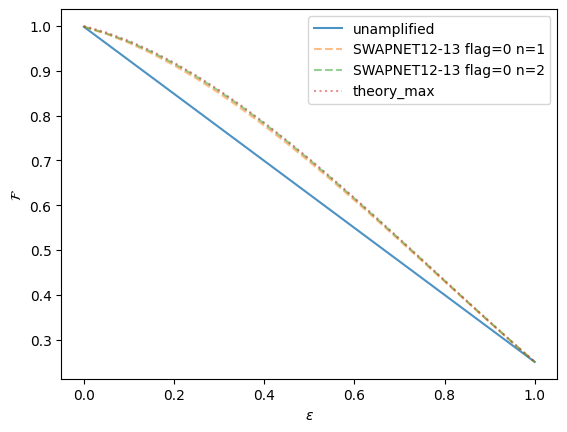

In [9]:

import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Kraus, SuperOp
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector,DensityMatrix,state_fidelity,partial_trace, Operator
from matplotlib import pyplot as plt
from functools import reduce
from scipy.linalg import expm
import pandas as pd

# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)


def tfim_circuit_with_noise_at_end(qc, n, m, J, h, t, p, epsilon):
    # Time increment for each Trotter step
    dt = t / p

    # Define the depolarizing error
    depolarizing = depolarizing_error(epsilon, 1)
    two_qubit_depolarizing = depolarizing_error(epsilon, 2)

    for step in range(p):
        # Apply the ZZ coupling terms with noise
        for i in range(n,m):
            qc.rzz(2 * -J * dt, i, i + 1)

        # Apply the transverse field terms with noise
        for i in range(n,m+1):
            qc.rx(2 * -h * dt, i)
    qc.append(two_qubit_depolarizing, [n, m])

    return qc

def tfim_circuit_with_gate_noise(qc, n, m, J, h, t, p, epsilon):
    # Time increment for each Trotter step
    dt = t / p

    # Define the depolarizing error
    depolarizing = depolarizing_error(epsilon, 1)
    two_qubit_depolarizing = depolarizing_error(epsilon, 2)

    for step in range(p):
        # Apply the ZZ coupling terms with noise
        for i in range(n,m):
            qc.rzz(2 * -J * dt, i, i + 1)
            qc.append(two_qubit_depolarizing, [i, i+1])

        # Apply the transverse field terms with noise
        for i in range(n,m+1):
            qc.rx(2 * -h * dt, i)
            qc.append(depolarizing, [i])

    return qc

def construct_hamiltonian(N, J, h):

    #definitions
    sigma_x = np.array([[0, 1], [1, 0]])
    sigma_z = np.array([[1, 0], [0, -1]])
    identity = np.eye(2)

    H = np.zeros((2**N, 2**N))

    # Interaction term: -J * sum(sigma_z[i] * sigma_z[i+1])
    for i in range(N):
        for j in range(i+1, N):
            term = 1
            for k in range(N):
                if k == i:
                    term = np.kron(term, sigma_z)
                elif k == j:
                    term = np.kron(term, sigma_z)
                else:
                    term = np.kron(term, identity)
            H += -J * term

    # Transverse field term: -h * sum(sigma_x[i])
    for i in range(N):
        term = 1
        for j in range(N):
            if j == i:
                term = np.kron(term, sigma_x)
            else:
                term = np.kron(term, identity)
        H += -h * term

    return H

def getExactState(n_qubits, J, h, time):
    hamiltonian = construct_hamiltonian(n_qubits, J, h)

    # Exact time evolution using matrix exponentiation
    exact_operator = expm(-1j * time * hamiltonian)

    # Create an initial state (|00...0>)
    initial_state = np.zeros(2**n_qubits)
    initial_state[0] = 1

    # Apply exact time evolution
    pure_state = exact_operator @ initial_state
    pure_state = DensityMatrix(pure_state)

    return pure_state

# Input state without purification, used for benchmarking

def getInputRho(epsilon, t, N, gate_noise=0):

    # Create a Quantum Circuit acting on a quantum register of 2 qubits
    qc = QuantumCircuit(2)

    if gate_noise==0:
        qc=tfim_circuit_with_noise_at_end(qc, 0, 1, J, h, t, N, epsilon)
    else:
        qc=tfim_circuit_with_gate_noise(qc, 0, 1, J, h, t, N, epsilon)

    state = DensityMatrix(qc)

    return state


def getPurifiedRhoWithSWAP1213GHZ(epsilon,n,N,flag):

    list_rho_odd=[]
    list_rho_even=[]
    list_p00or11_odd=[]
    list_p00or11_even=[]
    list_p01or10_odd=[]
    list_p01or10_even=[]

    qc_odd = QuantumCircuit(8)
    qc_odd.reset(0)
    qc_odd.reset(1)

    # Apply the Hadamard gate to the first and second qubits
    qc_odd.h(0)
    qc_odd.cx(0,1)

    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_odd.cswap(0, 2, 4)

    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_odd.cswap(1, 3, 5)

    # Apply the second Hadamard gate to the first and second qubits
    qc_odd.h(0)
    qc_odd.h(1)

    qc_even = QuantumCircuit(8)
    qc_even.reset(0)
    qc_even.reset(1)
    # Apply the Hadamard gate to the first and second qubits
    qc_even.h(0)
    qc_even.cx(0,1)

    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc_even.cswap(0, 2, 6)

    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc_even.cswap(1, 3, 7)

    # Apply the second Hadamard gate to the first and second qubit
    qc_even.h(0)
    qc_even.h(1)

    # Create a Quantum Circuit acting on a quantum register of five qubits
    qc = QuantumCircuit(8)

    qc=tfim_circuit_with_noise_at_end(qc, 2, 3, J, h, t, N, epsilon)
    qc=tfim_circuit_with_noise_at_end(qc, 4, 5, J, h, t, N, epsilon)
    qc=tfim_circuit_with_noise_at_end(qc, 6, 7, J, h, t, N, epsilon)

    # Apply the Hadamard gate to the first and second qubits
    qc.h(0)
    qc.cx(0,1)

    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc.cswap(0, 2, 4)

    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc.cswap(1, 3, 5)

    # Apply the second Hadamard gate to the first and second qubits
    qc.h(0)
    qc.h(1)

    state = DensityMatrix(qc)

    # Define the |0><0| projection matrix for a single qubit
    P0 = np.array([[1, 0],
                   [0, 0]])
    P1 = np.array([[0, 0],
                   [0, 1]])

    # Define the 2x2 identity matrix
    I = np.eye(2)

    # Create the 8-qubit projection operator using tensor products
    projection_operator00 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0)).tensor(Operator(P0))
    projection_operator01 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1)).tensor(Operator(P0))
    projection_operator10 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0)).tensor(Operator(P1))
    projection_operator11 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1)).tensor(Operator(P1))

    projected_rho00=projection_operator00@state@projection_operator00.adjoint()
    prob_00=np.trace(projection_operator00@state@projection_operator00)
    post_meas_rho00=projected_rho00/prob_00

    projected_rho01=projection_operator01@state@projection_operator01.adjoint()
    prob_01=np.trace(projection_operator01@state@projection_operator01)
    post_meas_rho01=projected_rho01/prob_01

    projected_rho10=projection_operator10@state@projection_operator10.adjoint()
    prob_10=np.trace(projection_operator10@state@projection_operator10)
    post_meas_rho10=projected_rho10/prob_10

    projected_rho11=projection_operator11@state@projection_operator11.adjoint()
    prob_11=np.trace(projection_operator11@state@projection_operator11)
    post_meas_rho11=projected_rho11/prob_11

    list_p00or11_odd.append(prob_00+prob_11)
    list_p01or10_odd.append(prob_10+prob_01)

    # Trace out qubits q0, q1, q2, q3, q4 and q5
    list_rho_odd.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 4, 5]))
    # update the state
    state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))

    state=state.evolve(qc_even)

    projected_rho00=projection_operator00@state@projection_operator00.adjoint()
    prob_00=np.trace(projection_operator00@state@projection_operator00)
    post_meas_rho00=projected_rho00/prob_00

    projected_rho01=projection_operator01@state@projection_operator01.adjoint()
    prob_01=np.trace(projection_operator01@state@projection_operator01)
    post_meas_rho01=projected_rho01/prob_01

    projected_rho10=projection_operator10@state@projection_operator10.adjoint()
    prob_10=np.trace(projection_operator10@state@projection_operator10)
    post_meas_rho10=projected_rho10/prob_10

    projected_rho11=projection_operator11@state@projection_operator11.adjoint()
    prob_11=np.trace(projection_operator11@state@projection_operator11)
    post_meas_rho11=projected_rho11/prob_11

    list_p00or11_even.append(prob_00+prob_11)
    list_p01or10_even.append(prob_10+prob_01)

    # Trace out qubits q0, q1, q2, q3, q6, and q7
    list_rho_even.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 6, 7]))

    # update the state
    state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))

    for i in range(n-1):
            # Block A

            state=state.evolve(qc_odd)

            projected_rho00=projection_operator00@state@projection_operator00.adjoint()
            prob_00=np.trace(projection_operator00@state@projection_operator00)
            post_meas_rho00=projected_rho00/prob_00

            projected_rho01=projection_operator01@state@projection_operator01.adjoint()
            prob_01=np.trace(projection_operator01@state@projection_operator01)
            post_meas_rho01=projected_rho01/prob_01

            projected_rho10=projection_operator10@state@projection_operator10.adjoint()
            prob_10=np.trace(projection_operator10@state@projection_operator10)
            post_meas_rho10=projected_rho10/prob_10

            projected_rho11=projection_operator11@state@projection_operator11.adjoint()
            prob_11=np.trace(projection_operator11@state@projection_operator11)
            post_meas_rho11=projected_rho11/prob_11

            list_p00or11_odd.append(prob_00+prob_11)
            list_p01or10_odd.append(prob_10+prob_01)

            # Trace out qubits q0, q1, q2, q3, q4 and q5
            list_rho_odd.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 4, 5]))

            # update the state
            state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))

            # Block B
            state=state.evolve(qc_even)

            projected_rho00=projection_operator00@state@projection_operator00.adjoint()
            prob_00=np.trace(projection_operator00@state@projection_operator00)
            post_meas_rho00=projected_rho00/prob_00

            projected_rho01=projection_operator01@state@projection_operator01.adjoint()
            prob_01=np.trace(projection_operator01@state@projection_operator01)
            post_meas_rho01=projected_rho01/prob_01

            projected_rho10=projection_operator10@state@projection_operator10.adjoint()
            prob_10=np.trace(projection_operator10@state@projection_operator10)
            post_meas_rho10=projected_rho10/prob_10

            projected_rho11=projection_operator11@state@projection_operator11.adjoint()
            prob_11=np.trace(projection_operator11@state@projection_operator11)
            post_meas_rho11=projected_rho11/prob_11



            list_p00or11_even.append(prob_00+prob_11)
            list_p01or10_even.append(prob_10+prob_01)


            # Trace out qubits q0, q1, q2, q3, q6, and q7
            list_rho_even.append(partial_trace(DensityMatrix((projected_rho01+projected_rho10)/(prob_01+prob_10)), [0, 1, 2, 3, 6, 7]))

            # update the state
            state=DensityMatrix((projected_rho00+projected_rho11)/(prob_00+prob_11))


    purified_rho=list_p01or10_odd[0]*list_rho_odd[0]
    purified_rho=purified_rho+list_p00or11_odd[0]*list_p01or10_even[0]*list_rho_even[0]

    for j in range(n-1):
        #print(j)
        product_list_p00or11_odd=reduce(lambda x, y: x * y, list_p00or11_odd[:j+1])
        product_list_p00or11_even=reduce(lambda x, y: x * y, list_p00or11_even[:j+1])
        product_list_p00or11=product_list_p00or11_odd*product_list_p00or11_even

        purified_rho=purified_rho+product_list_p00or11*list_p01or10_odd[j+1]*list_rho_odd[j+1]
        purified_rho=purified_rho+product_list_p00or11*list_p00or11_odd[j+1]*list_p01or10_even[j+1]*list_rho_even[j+1]

    product_list_p00or11_odd=reduce(lambda x, y: x * y, list_p00or11_odd[:n])
    product_list_p00or11_even=reduce(lambda x, y: x * y, list_p00or11_even[:n])
    product_list_p00or11=product_list_p00or11_odd*product_list_p00or11_even

    if flag > 0:
        purified_rho=partial_trace(state, [0, 1, 4, 5, 6, 7])
    else:
        purified_rho=purified_rho+product_list_p00or11*partial_trace(state, [0, 1, 2, 3, 4, 5])

    return DensityMatrix(purified_rho)



#Simultation code
t=1
J=1
h=1
N=10
list_of_epsilon=[i * 0.05 for i in range(21)]
list_of_purified_fidelity_flag0=[]
list_of_purified_fidelity_flag0_n1=[]
list_of_purified_fidelity_flag0_n2=[]
list_of_purified_fidelity_theory=[]
list_of_fidelity=[]

pure_state =getExactState(2, J, h, t)

for i in list_of_epsilon:
    list_of_purified_fidelity_flag0_n1.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ(i,1,N,0), pure_state))
    list_of_purified_fidelity_flag0_n2.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ(i,2,N,0), pure_state))
    list_of_purified_fidelity_flag0.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ(i,10,N,0), pure_state))
    list_of_purified_fidelity_theory.append(1/8*(-2+i)*(1+i)*(-4+3*i))
    list_of_fidelity.append(state_fidelity(getInputRho(i, t, N), pure_state))



plt.plot(list_of_epsilon,list_of_fidelity,label='unamplified', alpha=0.8)
plt.plot(list_of_epsilon,list_of_purified_fidelity_flag0_n1,label='SWAPNET12-13 flag=0 n='+str(1), alpha=0.5, linestyle='dashed')
plt.plot(list_of_epsilon,list_of_purified_fidelity_flag0_n2,label='SWAPNET12-13 flag=0 n='+str(2), alpha=0.5, linestyle='dashed')
plt.plot(list_of_epsilon,list_of_purified_fidelity_theory,label='theory_max', alpha=0.5, linestyle='dotted')

plt.xlabel("$\\epsilon$")
plt.ylabel("$\\mathcal{F}$")
plt.legend()

# Lindblad, depolarizing

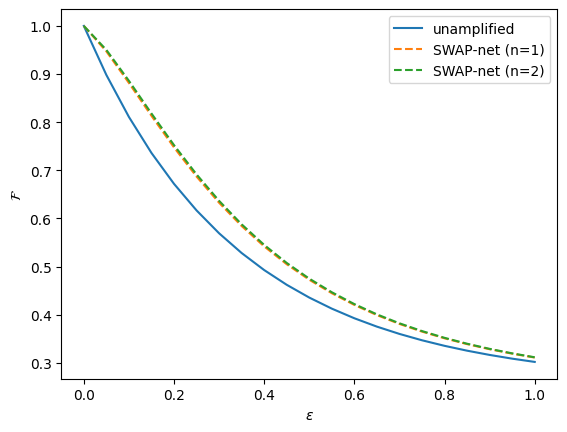

In [10]:
# ------------------------------------------------------------
#  Dependencies
# ------------------------------------------------------------
import numpy as np
from functools import reduce
from scipy.linalg import expm

from qiskit import QuantumCircuit
from qiskit.quantum_info import (
    DensityMatrix, Operator, Statevector,
    state_fidelity, partial_trace
)
from matplotlib import pyplot as plt

# ------------------------------------------------------------
#  1.  Pauli operators and two‑qubit TFIM Hamiltonian
# ------------------------------------------------------------
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)


def hamiltonian_tfim_two_qubit(J: float, h: float) -> np.ndarray:
    return (
        -J * np.kron(Z, Z)
        - h * (np.kron(X, I2) + np.kron(I2, X))
    )

# ------------------------------------------------------------
#  2.  Lindblad master‑equation solver
# ------------------------------------------------------------
def _lindblad_super(L: np.ndarray, d: int) -> np.ndarray:
    return (
        np.kron(L, L.conj())
        - 0.5 * np.kron(np.eye(d), L.conj().T @ L)
        - 0.5 * np.kron((L.conj().T @ L).T, np.eye(d))
    )


def solve_lindblad_tfim_pair(J: float, h: float, t: float, eps: float) -> DensityMatrix:
    d = 4
    H = hamiltonian_tfim_two_qubit(J, h)

    L = -1j * (np.kron(H, np.eye(d)) - np.kron(np.eye(d), H.T))

    gamma = eps / t                     # depolarising rate
    for P in (X, Y, Z):
        L += _lindblad_super(np.sqrt(gamma / 2) * np.kron(P, I2), d)
        L += _lindblad_super(np.sqrt(gamma / 2) * np.kron(I2, P), d)

    rho0 = np.zeros((d, d), dtype=complex)
    rho0[0, 0] = 1.0
    rho_t = (expm(L * t) @ rho0.flatten()).reshape(d, d)

    rho_t = 0.5 * (rho_t + rho_t.conj().T)
    rho_t /= np.trace(rho_t)
    return DensityMatrix(rho_t)

# ------------------------------------------------------------
#  3.  SWAP‑network purification (trace‑1 fixes)
# ------------------------------------------------------------
def getPurifiedRhoWithSWAP1213GHZ_Lindblad(eps, n, J, h, t, flag=0):
    # ----- initial 8‑qubit state -----
    ancilla = DensityMatrix.from_label('00')
    pair_rho = solve_lindblad_tfim_pair(J, h, t, eps)
    # state = ancilla.tensor(pair_rho).tensor(pair_rho).tensor(pair_rho)
    state = pair_rho.tensor(pair_rho).tensor(pair_rho).tensor(ancilla)

    # ----- GHZ + first CSWAP pair -----
    qc_init = QuantumCircuit(8)
    qc_init.h(0);  qc_init.cx(0, 1)
    qc_init.cswap(0, 2, 4);  qc_init.cswap(1, 3, 5)
    qc_init.h(0);  qc_init.h(1)
    state = state.evolve(qc_init)

    # ----- reusable odd / even blocks -----
    qc_odd, qc_even = QuantumCircuit(8), QuantumCircuit(8)
    for qc, tgt4, tgt5 in ((qc_odd, 4, 5), (qc_even, 6, 7)):
        qc.reset([0, 1])
        qc.h(0);  qc.cx(0, 1)
        qc.cswap(0, 2, tgt4);  qc.cswap(1, 3, tgt5)
        qc.h(0);  qc.h(1)

    # ----- projectors on qubits 6 & 7 -----
    P0, P1, I = np.array([[1, 0], [0, 0]]), np.array([[0, 0], [0, 1]]), np.eye(2)
    proj = lambda a, b: Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(
        Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(
        Operator(a)).tensor(Operator(b))
    P_00, P_01, P_10, P_11 = proj(P0, P0), proj(P1, P0), proj(P0, P1), proj(P1, P1)

    # ----- helpers & containers -----
    list_rho_odd, list_rho_even = [], []
    list_p00or11_odd, list_p00or11_even = [], []
    list_p01or10_odd, list_p01or10_even = [], []

    def projection_step(rho: DensityMatrix):
        proj_rhos = [P @ rho @ P.adjoint() for P in (P_00, P_01, P_10, P_11)]
        probs = [np.trace(M.data).real for M in proj_rhos]
        # normalised post‑measurement states
        posts = [DensityMatrix(M.data / p) if p > 0 else DensityMatrix.from_label('0' * 8)
                 for M, p in zip(proj_rhos, probs)]
        return probs, posts

    # ----- first projection (after qc_init) -----
    probs, posts = projection_step(state)
    p00, p01, p10, p11 = probs
    list_p00or11_odd.append(p00 + p11)
    list_p01or10_odd.append(p01 + p10)

    mix_odd = DensityMatrix((p01 * posts[1].data + p10 * posts[2].data) / (p01 + p10) if p01 + p10 else posts[1].data)
    list_rho_odd.append(partial_trace(mix_odd, [0, 1, 2, 3, 4, 5]))

    state = DensityMatrix((p00 * posts[0].data + p11 * posts[3].data) / (p00 + p11) if p00 + p11 else posts[0].data)

    # ----- iterate swap network -----
    for blk in range(n):
        # even block
        state = state.evolve(qc_even)
        probs, posts = projection_step(state)
        p00, p01, p10, p11 = probs
        list_p00or11_even.append(p00 + p11)
        list_p01or10_even.append(p01 + p10)

        mix_even = DensityMatrix((p01 * posts[1].data + p10 * posts[2].data) / (p01 + p10) if p01 + p10 else posts[1].data)
        list_rho_even.append(partial_trace(mix_even, [0, 1, 2, 3, 6, 7]))

        state = DensityMatrix((p00 * posts[0].data + p11 * posts[3].data) / (p00 + p11) if p00 + p11 else posts[0].data)

        # odd block (skip after last even)
        if blk < n - 1:
            state = state.evolve(qc_odd)
            probs, posts = projection_step(state)
            p00, p01, p10, p11 = probs
            list_p00or11_odd.append(p00 + p11)
            list_p01or10_odd.append(p01 + p10)

            mix_odd = DensityMatrix((p01 * posts[1].data + p10 * posts[2].data) / (p01 + p10) if p01 + p10 else posts[1].data)
            list_rho_odd.append(partial_trace(mix_odd, [0, 1, 2, 3, 4, 5]))

            state = DensityMatrix((p00 * posts[0].data + p11 * posts[3].data) / (p00 + p11) if p00 + p11 else posts[0].data)

    # ----- classical post‑processing -----
    purified_rho = (
        list_p01or10_odd[0] * list_rho_odd[0]
        + list_p00or11_odd[0] * list_p01or10_even[0] * list_rho_even[0]
    )

    for j in range(n - 1):
        prod_odd = reduce(lambda x, y: x * y, list_p00or11_odd[: j + 1])
        prod_even = reduce(lambda x, y: x * y, list_p00or11_even[: j + 1])
        coeff = prod_odd * prod_even

        purified_rho += coeff * list_p01or10_odd[j + 1] * list_rho_odd[j + 1]
        purified_rho += coeff * list_p00or11_odd[j + 1] * list_p01or10_even[j + 1] * list_rho_even[j + 1]

    if flag > 0:
        purified_rho = partial_trace(state, [0, 1, 4, 5, 6, 7])
    else:
        coeff = reduce(lambda x, y: x * y, list_p00or11_odd) * reduce(lambda x, y: x * y, list_p00or11_even)
        purified_rho += coeff * partial_trace(state, [0, 1, 2, 3, 4, 5])

    return DensityMatrix(purified_rho)

# ------------------------------------------------------------
#  4.  Benchmark / plot
# ------------------------------------------------------------
t, J, h = 1.0, 1.0, 1.0
eps_list = [0.05 * k for k in range(21)]
# eps_list = [0.005 * k for k in range(21)]


# exact closed‑system reference
U = expm(-1j * hamiltonian_tfim_two_qubit(J, h) * t)
psi0 = np.zeros(4, dtype=complex);  psi0[0] = 1.0
pure_state = Statevector(U @ psi0)

fid_unamp, fid_pur1, fid_pur2 = [], [], []

for eps in eps_list:
    fid_unamp.append(state_fidelity(solve_lindblad_tfim_pair(J, h, t, eps), pure_state))
    fid_pur1.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ_Lindblad(eps, 1, J, h, t), pure_state))
    fid_pur2.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ_Lindblad(eps, 2, J, h, t), pure_state))

plt.plot(eps_list, fid_unamp, label="unamplified")
plt.plot(eps_list, fid_pur1, "--", label="SWAP‑net (n=1)")
plt.plot(eps_list, fid_pur2, "--", label="SWAP‑net (n=2)")
plt.xlabel(r"$\epsilon$");  plt.ylabel(r"$\mathcal{F}$");  plt.legend();  plt.show()


# Lindblad, dephasing

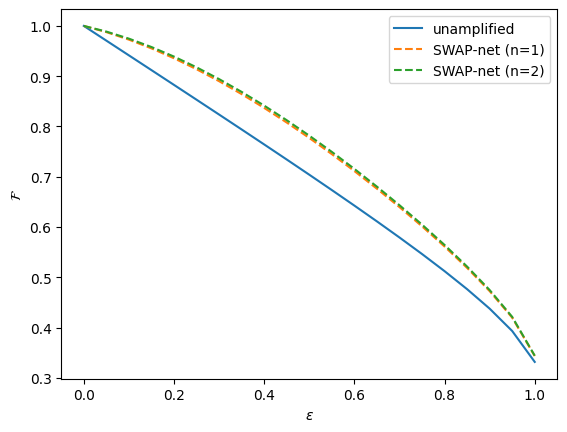

In [11]:
# ------------------------------------------------------------
#  Dependencies
# ------------------------------------------------------------
import numpy as np
from functools import reduce
from scipy.linalg import expm

from qiskit import QuantumCircuit
from qiskit.quantum_info import (
    DensityMatrix, Operator, Statevector,
    state_fidelity, partial_trace
)
from matplotlib import pyplot as plt

# ------------------------------------------------------------
#  1.  Pauli operators and two‑qubit TFIM Hamiltonian
# ------------------------------------------------------------
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)


def hamiltonian_tfim_two_qubit(J: float, h: float) -> np.ndarray:
    return (
        -J * np.kron(Z, Z)
        - h * (np.kron(X, I2) + np.kron(I2, X))
    )

# ------------------------------------------------------------
#  2.  Lindblad master‑equation solver
# ------------------------------------------------------------
def _lindblad_super(L: np.ndarray, d: int) -> np.ndarray:
    return (
        np.kron(L, L.conj())
        - 0.5 * np.kron(np.eye(d), L.conj().T @ L)
        - 0.5 * np.kron((L.conj().T @ L).T, np.eye(d))
    )


def solve_lindblad_tfim_pair(J: float, h: float, t: float, eps: float) -> DensityMatrix:
    d = 4
    H = hamiltonian_tfim_two_qubit(J, h)

    L = -1j * (np.kron(H, np.eye(d)) - np.kron(np.eye(d), H.T))

    gamma = eps / t                     # depolarising rate
    for P in (X, Y, Z):
        L += _lindblad_super(np.sqrt(gamma / 2) * np.kron(P, I2), d)
        L += _lindblad_super(np.sqrt(gamma / 2) * np.kron(I2, P), d)

    rho0 = np.zeros((d, d), dtype=complex)
    rho0[0, 0] = 1.0
    rho_t = (expm(L * t) @ rho0.flatten()).reshape(d, d)

    rho_t = 0.5 * (rho_t + rho_t.conj().T)
    rho_t /= np.trace(rho_t)
    return DensityMatrix(rho_t)

# ------------------------------------------------------------
#  2.  Lindblad master‑equation solver  *pure dephasing*
# ------------------------------------------------------------
def _lindblad_super(L: np.ndarray, d: int) -> np.ndarray:
    """Column‑vector super‑operator for one jump operator L."""
    return (
        np.kron(L, L.conj())
        - 0.5 * np.kron(np.eye(d), L.conj().T @ L)
        - 0.5 * np.kron((L.conj().T @ L).T, np.eye(d))
    )

def solve_lindblad_tfim_pair(J: float, h: float, t: float, eps: float) -> DensityMatrix:
    """
    Two‑qubit TFIM unitary + **pure dephasing** on each qubit.
    The dephasing strength is calibrated so that in the single‑qubit
    limit ε equals the usual Kraus‑parameter `p` of the channel
        ρ → (1‑p)ρ + p ZρZ .
    """
    d = 4
    H = hamiltonian_tfim_two_qubit(J, h)

    # Hamiltonian Liouvillian
    L = -1j * (np.kron(H, np.eye(d)) - np.kron(np.eye(d), H.T))

    # Convert ε (Kraus parameter) to a Lindblad rate  γ  via
    #     p = 1 - exp(-2γt)  ⇒  γ = -½ ln(1-ε) / t
    gamma = -0.5 * np.log(max(1 - eps, 1e-12)) / t

    # Single‑qubit dephasing jump operator  √γ Z
    L += _lindblad_super(np.sqrt(gamma) * np.kron(Z, I2), d)
    L += _lindblad_super(np.sqrt(gamma) * np.kron(I2, Z), d)

    # Propagate the vectorised density matrix
    rho0 = np.zeros((d, d), dtype=complex);  rho0[0, 0] = 1.0
    rho_t = (expm(L * t) @ rho0.flatten()).reshape(d, d)

    # Hermiticity & trace‑1 hygiene
    rho_t = 0.5 * (rho_t + rho_t.conj().T)
    rho_t /= np.trace(rho_t)
    return DensityMatrix(rho_t)


# ------------------------------------------------------------
#  3.  SWAP‑network purification (trace‑1 fixes)
# ------------------------------------------------------------
def getPurifiedRhoWithSWAP1213GHZ_Lindblad(eps, n, J, h, t, flag=0):
    # ----- initial 8‑qubit state -----
    ancilla = DensityMatrix.from_label('00')
    pair_rho = solve_lindblad_tfim_pair(J, h, t, eps)
    # state = ancilla.tensor(pair_rho).tensor(pair_rho).tensor(pair_rho)
    state = pair_rho.tensor(pair_rho).tensor(pair_rho).tensor(ancilla)

    # ----- GHZ + first CSWAP pair -----
    qc_init = QuantumCircuit(8)
    qc_init.h(0);  qc_init.cx(0, 1)
    qc_init.cswap(0, 2, 4);  qc_init.cswap(1, 3, 5)
    qc_init.h(0);  qc_init.h(1)
    state = state.evolve(qc_init)

    # ----- reusable odd / even blocks -----
    qc_odd, qc_even = QuantumCircuit(8), QuantumCircuit(8)
    for qc, tgt4, tgt5 in ((qc_odd, 4, 5), (qc_even, 6, 7)):
        qc.reset([0, 1])
        qc.h(0);  qc.cx(0, 1)
        qc.cswap(0, 2, tgt4);  qc.cswap(1, 3, tgt5)
        qc.h(0);  qc.h(1)

    # ----- projectors on qubits 6 & 7 -----
    P0, P1, I = np.array([[1, 0], [0, 0]]), np.array([[0, 0], [0, 1]]), np.eye(2)
    proj = lambda a, b: Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(
        Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(
        Operator(a)).tensor(Operator(b))
    P_00, P_01, P_10, P_11 = proj(P0, P0), proj(P1, P0), proj(P0, P1), proj(P1, P1)

    # ----- helpers & containers -----
    list_rho_odd, list_rho_even = [], []
    list_p00or11_odd, list_p00or11_even = [], []
    list_p01or10_odd, list_p01or10_even = [], []

    def projection_step(rho: DensityMatrix):
        proj_rhos = [P @ rho @ P.adjoint() for P in (P_00, P_01, P_10, P_11)]
        probs = [np.trace(M.data).real for M in proj_rhos]
        # normalised post‑measurement states
        posts = [DensityMatrix(M.data / p) if p > 0 else DensityMatrix.from_label('0' * 8)
                 for M, p in zip(proj_rhos, probs)]
        return probs, posts

    # ----- first projection (after qc_init) -----
    probs, posts = projection_step(state)
    p00, p01, p10, p11 = probs
    list_p00or11_odd.append(p00 + p11)
    list_p01or10_odd.append(p01 + p10)

    mix_odd = DensityMatrix((p01 * posts[1].data + p10 * posts[2].data) / (p01 + p10) if p01 + p10 else posts[1].data)
    list_rho_odd.append(partial_trace(mix_odd, [0, 1, 2, 3, 4, 5]))

    state = DensityMatrix((p00 * posts[0].data + p11 * posts[3].data) / (p00 + p11) if p00 + p11 else posts[0].data)

    # ----- iterate swap network -----
    for blk in range(n):
        # even block
        state = state.evolve(qc_even)
        probs, posts = projection_step(state)
        p00, p01, p10, p11 = probs
        list_p00or11_even.append(p00 + p11)
        list_p01or10_even.append(p01 + p10)

        mix_even = DensityMatrix((p01 * posts[1].data + p10 * posts[2].data) / (p01 + p10) if p01 + p10 else posts[1].data)
        list_rho_even.append(partial_trace(mix_even, [0, 1, 2, 3, 6, 7]))

        state = DensityMatrix((p00 * posts[0].data + p11 * posts[3].data) / (p00 + p11) if p00 + p11 else posts[0].data)

        # odd block (skip after last even)
        if blk < n - 1:
            state = state.evolve(qc_odd)
            probs, posts = projection_step(state)
            p00, p01, p10, p11 = probs
            list_p00or11_odd.append(p00 + p11)
            list_p01or10_odd.append(p01 + p10)

            mix_odd = DensityMatrix((p01 * posts[1].data + p10 * posts[2].data) / (p01 + p10) if p01 + p10 else posts[1].data)
            list_rho_odd.append(partial_trace(mix_odd, [0, 1, 2, 3, 4, 5]))

            state = DensityMatrix((p00 * posts[0].data + p11 * posts[3].data) / (p00 + p11) if p00 + p11 else posts[0].data)

    # ----- classical post‑processing -----
    purified_rho = (
        list_p01or10_odd[0] * list_rho_odd[0]
        + list_p00or11_odd[0] * list_p01or10_even[0] * list_rho_even[0]
    )

    for j in range(n - 1):
        prod_odd = reduce(lambda x, y: x * y, list_p00or11_odd[: j + 1])
        prod_even = reduce(lambda x, y: x * y, list_p00or11_even[: j + 1])
        coeff = prod_odd * prod_even

        purified_rho += coeff * list_p01or10_odd[j + 1] * list_rho_odd[j + 1]
        purified_rho += coeff * list_p00or11_odd[j + 1] * list_p01or10_even[j + 1] * list_rho_even[j + 1]

    if flag > 0:
        purified_rho = partial_trace(state, [0, 1, 4, 5, 6, 7])
    else:
        coeff = reduce(lambda x, y: x * y, list_p00or11_odd) * reduce(lambda x, y: x * y, list_p00or11_even)
        purified_rho += coeff * partial_trace(state, [0, 1, 2, 3, 4, 5])

    return DensityMatrix(purified_rho)

# ------------------------------------------------------------
#  4.  Benchmark / plot
# ------------------------------------------------------------
t, J, h = 1.0, 1.0, 1.0
eps_list = [0.05 * k for k in range(21)]
eps_list = [0.05 * k for k in range(21)]


# exact closed‑system reference
U = expm(-1j * hamiltonian_tfim_two_qubit(J, h) * t)
psi0 = np.zeros(4, dtype=complex);  psi0[0] = 1.0
pure_state = Statevector(U @ psi0)

fid_unamp, fid_pur1, fid_pur2 = [], [], []

for eps in eps_list:
    fid_unamp.append(state_fidelity(solve_lindblad_tfim_pair(J, h, t, eps), pure_state))
    fid_pur1.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ_Lindblad(eps, 1, J, h, t), pure_state))
    fid_pur2.append(state_fidelity(getPurifiedRhoWithSWAP1213GHZ_Lindblad(eps, 2, J, h, t), pure_state))

plt.plot(eps_list, fid_unamp, label="unamplified")
plt.plot(eps_list, fid_pur1, "--", label="SWAP‑net (n=1)")
plt.plot(eps_list, fid_pur2, "--", label="SWAP‑net (n=2)")
plt.xlabel(r"$\epsilon$");  plt.ylabel(r"$\mathcal{F}$");  plt.legend();  plt.show()
